# Approximate Bayesian Computation by Subset Simulation 

### 1. Initial Setup

In [26]:
import random
import math
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import time

start_time = time.time()

### 2.1 Activation Functions

This section defines the classic activation functions and their derivatives:

- **Sigmoid**: compresses real values to the range (0, 1).  
- **Tanh**: compresses values to the range (-1, 1).  
- **ReLU**: rectifies negative values to zero and passes positive values through.  

Each function is defined as a tuple `(function, derivative)` for convenient use
in forward propagation and backpropagation.


In [27]:
sigmoid = (
    lambda x: 1
    / (1 + np.exp(-x)),  # Sigmoid function: compresses values to range (0,1)
    lambda x: x * (1 - x),  # Sigmoid derivative: needed for backpropagation
)

tanh = (
    lambda x: (np.exp(x) - np.exp(-x))
    / (np.exp(x) + np.exp(-x)),  # Hyperbolic tangent function (-1,1)
    lambda x: 1
    - ((np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))) ** 2,  # Tanh derivative
)


def derivada_relu(x):
    # ReLU derivative: 0 if x<=0, 1 if x>0
    x[x <= 0] = 0
    x[x > 0] = 1
    return x


relu = (
    lambda x: x * (x > 0),  # ReLU function: passes positives and zeroes out negatives
    lambda x: derivada_relu(x),  # ReLU derivative
)

### 2.2 Error Metric

The metric used to evaluate the quality of the model's predictions is defined here:

- **Mean Squared Error (MSE)**:  
  Computes the mean of the squared differences between predictions (`Yp`) and actual values (`Yr`).  
  A lower value indicates a better model fit.


In [28]:
def metric(Yp, Yr):
    # Computes the mean squared error (MSE)
    error = (
        np.array(Yp) - np.array(Yr)
    ) ** 2  # Squared difference between predictions and actual values
    error = np.mean(error)  # Average of the errors
    return error

### 2.3 Parameter Handling and Forward Pass Functions

This section defines utilities to convert the parameter vector into
weight and bias matrices, and the **forward propagation** function:

- **MatrixW**: transforms the flat weight vector into per-layer matrices.  
- **Matrixb**: transforms the flat bias vector into per-layer vectors.  
- **fpass**: performs the forward pass through the network
  applying weights, biases, and activation functions.


In [29]:
neurons = [1, 5, 5, 1]
act_func = [tanh, tanh, tanh]


def generate_colnames(neurons):
    """
    Generates column names in the same order they are used later in:
    - MatrixW (all weights per layer, in block).
    - Matrixb (all biases per layer, in block).
    """
    colnames = []

    # 1. Weights (all first)
    for l in range(len(neurons) - 1):
        for i in range(neurons[l]):
            for j in range(neurons[l + 1]):
                colnames.append(f"W{l}_{i}_{j}")

    # 2. Biases (all after weights)
    for l in range(len(neurons) - 1):
        for j in range(neurons[l + 1]):
            colnames.append(f"b{l + 1}_{j}")

    # 3. Error (last column in ABCSampAcc / ACC_Interm_SS)
    colnames.append("Error")

    return colnames


def MatrixW(W):
    # Converts the parameter vector W into weight matrices
    MatrixW = []
    ref = 0
    for i in range(len(neurons) - 1):
        x = W[
            ref : ref + (neurons[i + 1] * neurons[i])
        ]  # Extracts weights for the connection layer i → layer i+1
        x = x.reshape(
            (neurons[i], neurons[i + 1])
        )  # Reshapes into matrix (rows=input neuron, columns=output neuron)
        MatrixW.append(x)
        ref = ref + (neurons[i + 1] * neurons[i])  # Advances the index
    return MatrixW


def Matrixb(b):
    # Converts the parameter vector b into bias matrices
    Matrixb = []
    ref = 0
    for i in range(len(neurons) - 1):
        x = b[ref : ref + (neurons[i + 1])]  # Extracts the biases of the layer
        x = x.reshape((1, neurons[i + 1]))  # Row vector (1 x number_of_neurons_next_layer)
        Matrixb.append(x)
        ref = ref + (neurons[i + 1])
    return Matrixb


def fpass(X, W, b):
    # Forward propagation with weights W, biases b, and input data X
    # W and b must be previously transformed with MatrixW and Matrixb

    output = [X]
    # List that stores the output of each layer, starting with the input

    for count in range(len(neurons) - 1):
        z = output[-1] @ W[count] + b[count]  # Matrix product + bias
        a = act_func[count][0](z)  # Apply the corresponding activation function
        output.append(a)  # Store the activation
    return output[-1]  # Returns the final network output

### 2.4 Visualization Functions

Helper functions are defined to graphically represent the error distribution
across the different simulation levels:

- **plot_error_hist_all**  
  Shows the evolution of cumulative error distributions up to a given level.  
  - Rejected errors are drawn in gray.  
  - Accepted samples at each level are colored distinctly.  
  - Vertical lines represent the acceptance thresholds (ε).  

- **plot_error_hist**  
  Displays the error distribution at a specific level.  
  - Differentiates between accepted and rejected samples at that level.  
  - Includes vertical lines for the ε thresholds.  
  - Annotates the number of rejected samples on the plot.  

These functions allow for a clear analysis of how samples are filtered and accepted
throughout the simulation process.


In [30]:
def plot_error_hist_all(errors_all, epsilons, level=None, savepath=None):
    """
    Visualizes the error distribution up to a simulation level,
    excluding the prior (level 0) and coloring the accepted samples of each level.

    Parameters
    ----------
    errors_all : list of ndarrays
        List where each element contains the errors of a level (0..N).
    epsilons : list or ndarray
        Acceptance thresholds ε defined up to that level.
    level : int or None
        Current simulation level.
    savepath : str or None
        If not None, saves the figure to that path.
    """
    plt.figure(figsize=(8, 5))

    # Concatenate errors from level 1 to the current level (without prior 0)
    if level > 0:
        errors_concat = np.concatenate(errors_all[1 : level + 1])
    else:
        errors_concat = errors_all[0]

    # Histogram of rejected samples in gray
    plt.hist(
        errors_concat,
        bins=30,
        color="lightgray",
        edgecolor="black",
        label="Previous + current rejected",
    )

    # Color palette for levels
    colors = [
        "steelblue",
        "orange",
        "green",
        "crimson",
        "purple",
        "brown",
        "cyan",
        "pink",
    ]

    # Accepted at each level 1..level
    for i, eps in enumerate(epsilons):
        lvl_errors = errors_all[i + 1]  # actual level = i+1 (because 0 is prior)
        accepted = lvl_errors[lvl_errors <= eps]
        plt.hist(
            accepted,
            bins=30,
            alpha=0.7,
            color=colors[i % len(colors)],
            label=f"Accepted ε{i + 1} ≤ {eps:.4f} ({len(accepted)})",
        )
        plt.axvline(eps, color=colors[i % len(colors)], linestyle="--")

    plt.xlabel("Error (MSE)")
    plt.ylabel("Frequency")
    if level is not None:
        plt.title(f"Error distribution up to level {level} (without prior)")
    else:
        plt.title("Error distribution")
    plt.legend()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    else:
        plt.show()


def plot_error_hist(errors, epsilons, level=None, savepath=None):
    """
    Visualizes the error distribution and the cuts by ε thresholds,
    also showing how many samples have been accepted/rejected.

    Parameters
    ----------
    errors : ndarray, shape (N,)
        Errors of all samples at a simulation level.
    epsilons : list or ndarray
        List of acceptance thresholds ε defined up to that level.
    level : int or None
        Level number (to display in the plot title).
    savepath : str or None
        If not None, saves the figure to that path.
    """
    plt.figure(figsize=(8, 5))

    # Histogram of all samples (rejected by default)
    plt.hist(errors, bins=30, color="lightgray", edgecolor="black", label="Rejected")

    # Count accepted and rejected
    total = len(errors)
    for i, eps in enumerate(epsilons):
        accepted = errors[errors <= eps]
        rejected = errors[errors > eps]

        plt.hist(
            accepted,
            bins=30,
            alpha=0.6,
            label=f"Accepted ε{i + 1} ≤ {eps:.4f} ({len(accepted)})",
        )

        # Vertical line for the threshold
        plt.axvline(eps, color="red", linestyle="--")

        # Show rejected count only at the last epsilon
        if i == len(epsilons) - 1:
            plt.text(
                max(errors) * 0.8,
                plt.ylim()[1] * 0.9,
                f"Rejected: {len(rejected)}",
                color="gray",
            )

    plt.xlabel("Error (MSE)")
    plt.ylabel("Frequency")
    if level is not None:
        plt.title(f"Error distribution at level {level}")
    else:
        plt.title("Error distribution")
    plt.legend()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    else:
        plt.show()

### 3. Data

A synthetic dataset is generated to train and validate the model:

- **X**: 400 evenly spaced values in the range [-9, 9].  
- **Y**: cosine function values evaluated at `X` with Gaussian noise 
  (mean 0, std 0.01) to simulate real data.  
- Finally, they are converted to `float32` and reshaped as column vectors.


In [31]:
N_Inputs = 400
# Número de muestras de entrada (tamaño del dataset)

X = np.linspace(-3, 3, num=N_Inputs)
# Genera 400 valores equidistantes entre -3 y 3 (entrada de la red)

Y = np.cos(X) + np.random.normal(0, 0.01, size=N_Inputs)
# Salida deseada: coseno de X
# Se añade un poco de ruido gaussiano con media=0 y desviación=0.01
# para simular datos más realistas

X = X.astype(np.float32).reshape((N_Inputs, 1))
# Convierte X a tipo float32 y lo organiza como vector columna (400x1)

Y = Y.astype(np.float32).reshape((N_Inputs, 1))
# Convierte Y a tipo float32 y también lo organiza como vector columna (400x1)

### 4. Network Definition and Hyperparameters

The neural network architecture and main parameters of the
ABC-SubSim algorithm are established:

- **neurons**: list with the number of neurons per layer  
  (input → hidden → output).  
- **act_func**: activation functions assigned to each layer.  
- **P0**: percentage of samples used as seeds at each simulation level.  
- **N**: total number of samples per level.  
- **simlevls**: number of simulation levels.  
- **new_std**: initial standard deviation for parameter perturbation, decreasing across levels.


In [32]:
colnames = generate_colnames(neurons)
print("Generated names:", colnames[:10], "... total =", len(colnames))

act_func = act_func
# Activation functions for each layer (hidden and output in this case).
# Here tanh is used for both layers.

P0 = 0.2
# Percentage of samples used as "seeds" in subsequent simulation levels.

N = 100000
# Number of network configurations generated in each simulation

simlevls = 6
# Simulation levels to be executed (depth of the iterative process).

new_std = (simlevls + 1) * 0.1
# Proposed standard deviation for each simulation level.
# Increases with the number of levels.

Generated names: ['W0_0_0', 'W0_0_1', 'W0_0_2', 'W0_0_3', 'W0_0_4', 'W1_0_0', 'W1_0_1', 'W1_0_2', 'W1_0_3', 'W1_0_4'] ... total = 47


### 4.2 Number of Parameters

The total number of network parameters is computed:

- **nW**: total number of weights (connections between neurons).  
- **nb**: total number of biases (one per neuron in the hidden and output layers).  

The total is obtained by iterating over each connection between layers and accumulating the corresponding weights and biases.


In [33]:
nW = 0  # Weight counter
nb = 0  # Bias counter

for i in range(len(neurons) - 1):
    # Iterates over each connection between layers (input→hidden, hidden→output, etc.)

    p = neurons[i + 1] * neurons[i]
    # Number of weights between layer i and layer i+1
    # (each neuron in the next layer connects to all neurons in the current layer)

    nW = nW + p
    # Accumulates total weights

    nb = nb + neurons[i + 1]
    # Adds biases for the next layer (one per neuron)

print("Total number of weights (nW):", nW)
print("Total number of biases (nb):", nb)

Total number of weights (nW): 35
Total number of biases (nb): 11


### 5. Initialization (Prior)

The initial population of network parameters is defined:

- **ACC_Interm_SS**: 3D matrix that stores, for each simulation level,  
  all parameters (weights + biases) along with the error metric.  
  Dimensions:  
  - *simlevls+1*: simulation levels.  
  - *N*: number of samples.  
  - *nW+nb+1*: network parameters + 1 extra column for the error.  

- **ABCSampAcc**: 2D matrix that stores the parameters and metric at a single level.  
  It is overwritten at each iteration before being saved into `ACC_Interm_SS`.  

- The parameters (weights and biases) are initialized with a **truncated normal distribution** in [-1, 1], acting as the *prior* distribution.  

- Auxiliary lists are also created to store prediction results (`YFinal`) and errors (`eFinal`) at each level.

In [34]:
ACC_Interm_SS = np.zeros(shape=(simlevls + 1, N, nW + nb + 1))
# 3D matrix to store ALL parameters and metrics at each simulation level.
# Dimensions:
#   simlevls+1 → simulation levels
#   N → number of samples
#   nW+nb+1 → all parameters (weights + biases) + 1 extra column for the error/metric

ABCSampAcc = np.zeros(shape=(N, nW + nb + 1))
# 2D matrix that stores parameters and metric at a single simulation level.
# Overwritten at each level before being saved to ACC_Interm_SS.

for i in range(nW + nb):
    ABCSampAcc[:, i] = stats.truncnorm.rvs(-1, 1, loc=0, scale=1, size=N)
    # Initialization of parameters (weights and biases) with a truncated normal distribution in [-1, 1].
    # This acts as the "prior distribution" (initial belief distribution) for ABC.

YFinal = []
# List to store final outputs (for plotting later)

eFinal = []
# List to store final errors (for plotting later)

# Convert the numpy matrix to a DataFrame with column names
df_prior = pl.DataFrame({col: ACC_Interm_SS[0][:, idx] for idx, col in enumerate(colnames)})

# Visual inspection
print(df_prior)

shape: (100_000, 47)
┌────────┬────────┬────────┬────────┬───┬──────┬──────┬──────┬───────┐
│ W0_0_0 ┆ W0_0_1 ┆ W0_0_2 ┆ W0_0_3 ┆ … ┆ b2_3 ┆ b2_4 ┆ b3_0 ┆ Error │
│ ---    ┆ ---    ┆ ---    ┆ ---    ┆   ┆ ---  ┆ ---  ┆ ---  ┆ ---   │
│ f64    ┆ f64    ┆ f64    ┆ f64    ┆   ┆ f64  ┆ f64  ┆ f64  ┆ f64   │
╞════════╪════════╪════════╪════════╪═══╪══════╪══════╪══════╪═══════╡
│ 0.0    ┆ 0.0    ┆ 0.0    ┆ 0.0    ┆ … ┆ 0.0  ┆ 0.0  ┆ 0.0  ┆ 0.0   │
│ 0.0    ┆ 0.0    ┆ 0.0    ┆ 0.0    ┆ … ┆ 0.0  ┆ 0.0  ┆ 0.0  ┆ 0.0   │
│ 0.0    ┆ 0.0    ┆ 0.0    ┆ 0.0    ┆ … ┆ 0.0  ┆ 0.0  ┆ 0.0  ┆ 0.0   │
│ 0.0    ┆ 0.0    ┆ 0.0    ┆ 0.0    ┆ … ┆ 0.0  ┆ 0.0  ┆ 0.0  ┆ 0.0   │
│ 0.0    ┆ 0.0    ┆ 0.0    ┆ 0.0    ┆ … ┆ 0.0  ┆ 0.0  ┆ 0.0  ┆ 0.0   │
│ …      ┆ …      ┆ …      ┆ …      ┆ … ┆ …    ┆ …    ┆ …    ┆ …     │
│ 0.0    ┆ 0.0    ┆ 0.0    ┆ 0.0    ┆ … ┆ 0.0  ┆ 0.0  ┆ 0.0  ┆ 0.0   │
│ 0.0    ┆ 0.0    ┆ 0.0    ┆ 0.0    ┆ … ┆ 0.0  ┆ 0.0  ┆ 0.0  ┆ 0.0   │
│ 0.0    ┆ 0.0    ┆ 0.0    ┆ 0.0    ┆ … ┆ 0.0  ┆ 0.0  ┆ 

### 5.1 Prior Evaluation

The initial population of parameters is evaluated:

1. For each of the `N` samples:
   - Weights and biases are extracted from `ABCSampAcc`.
   - They are converted to matrix format with `MatrixW` and `Matrixb`.
   - The prediction is computed via the `forward pass`.
   - The mean squared error (MSE) is obtained with respect to the actual data.
   - The error is stored in the last column of the sample.

2. Finally, the entire initial population with its errors is stored at level 0 of `ACC_Interm_SS`.


shape: (100_000, 47)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ W0_0_0    ┆ W0_0_1    ┆ W0_0_2    ┆ W0_0_3    ┆ … ┆ b2_3      ┆ b2_4      ┆ b3_0      ┆ Error    │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ -0.634817 ┆ -0.222379 ┆ 0.387709  ┆ 0.01696   ┆ … ┆ -0.57682  ┆ -0.013225 ┆ -0.026815 ┆ 0.664109 │
│ -0.805411 ┆ -0.436637 ┆ 0.855187  ┆ -0.687393 ┆ … ┆ -0.799648 ┆ 0.041236  ┆ 0.071398  ┆ 0.821881 │
│ 0.791626  ┆ 0.156235  ┆ 0.353939  ┆ 0.086786  ┆ … ┆ -0.015909 ┆ 0.479935  ┆ -0.073072 ┆ 0.640007 │
│ 0.430115  ┆ -0.169098 ┆ 0.017625  ┆ 0.383058  ┆ … ┆ -0.820093 ┆ 0.826439  ┆ 0.439172  ┆ 0.787872 │
│ 0.021728  ┆ 0.457448  ┆ -0.634465 ┆ 0.784929  ┆ … ┆ -0.18542  ┆ 0.56

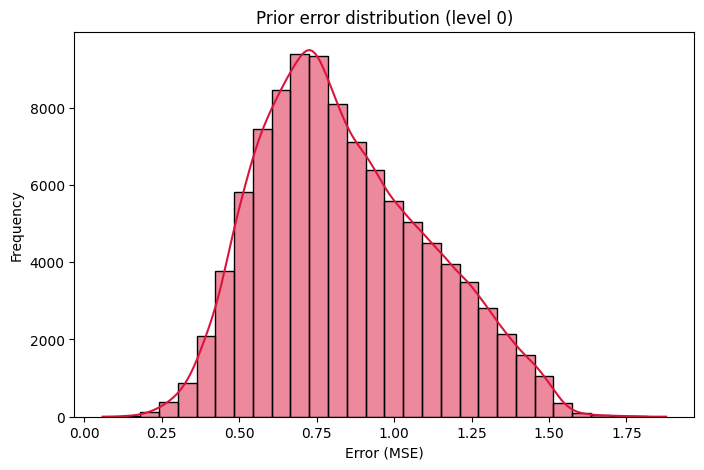

In [35]:
for i in range(N):
    # For each of the N initial parameter samples (prior)...

    W = ABCSampAcc[i, 0:nW]  # Extract weights
    b = ABCSampAcc[i, nW : nW + nb]  # Extract biases

    MW = MatrixW(W)  # Convert weights to matrices
    Mb = Matrixb(b)  # Convert biases to vectors

    Ypred = fpass(X, MW, Mb)  # Perform forward pass (network prediction)
    e = metric(Ypred, Y)  # Compute error (MSE)

    ABCSampAcc[i, nW + nb] = e  # Store error in the last column

# Store this first level (prior) in the global matrix
ACC_Interm_SS[0, :] = ABCSampAcc

# === Convert to DataFrame for visualization ===
df_prior = pl.DataFrame({col: ACC_Interm_SS[0][:, idx] for idx, col in enumerate(colnames)})

# Basic visualization
print(df_prior)  # first rows
print(df_prior.describe())  # statistical summary

# Prior error distribution (level 0)
plt.figure(figsize=(8, 5))
sns.histplot(df_prior["Error"], bins=30, kde=True, color="crimson", edgecolor="black")
plt.xlabel("Error (MSE)")
plt.ylabel("Frequency")
plt.title("Prior error distribution (level 0)")
plt.show()

### 5.2 Selection of the best initial model

Once the initial population has been evaluated:

1. All simulations are sorted according to their error (from lowest to highest).  
2. The parameters corresponding to the **best model** (lowest error) are selected.  
3. The selected parameters are converted into weight and bias matrices.  
4. A prediction is made with this best model.  
5. The output and the associated error are stored in the lists (`YFinal`, `eFinal`) for later visualization.

In [36]:
# Sort all simulations by error (from lowest to highest)
Ranked_ABCSampAcc = ABCSampAcc[ABCSampAcc[:, -1].argsort()]

# Take the parameters of the best initial model (lowest error)
Wtemp = Ranked_ABCSampAcc[0, 0:nW]
btemp = Ranked_ABCSampAcc[0, nW : nW + nb]

# Convert to matrix/vector format
MWtemp = MatrixW(Wtemp)
Mbtemp = Matrixb(btemp)

# Make the prediction of the best model
Ypred_temp = fpass(X, MWtemp, Mbtemp)

# Save results for plotting later
YFinal.append(Ypred_temp)
etemp = metric(Ypred_temp, Y)
eFinal.append(etemp)

# === Convert to DataFrame for inspection ===
colnames = generate_colnames(neurons)
df_ranked = pl.DataFrame(Ranked_ABCSampAcc, schema=colnames)

print("Best individual:")
print(df_ranked.row(0))  # parameters of the best model
print("\nTop 5 models:")
print(df_ranked.head(5)[["Error"]])  # error + first 5 W

Best individual:
(0.6724758388556917, -0.7311846436208632, 0.5762833203025997, -0.8935526929060377, 0.6860890747378422, 0.6174946167149256, 0.8761025911429966, 0.7039760108771855, 0.047742649194066906, -0.38945218789150043, -0.9652281521114896, 0.41084857706144684, 0.14004779083821334, -0.19845304477742562, 0.6307916434461732, -0.3006820161721599, 0.7563093910756533, -0.1234200873502504, -0.4414952176502502, 0.004395686157059578, 0.7473678713617359, -0.565615517871665, -0.2764555877735791, 0.9797846346836095, -0.07275600318931957, 0.14831003219421496, -0.15248050605460448, -0.5670703383611616, -0.12067988837801726, -0.506573661836778, -0.9123006207056615, 0.36558095744086366, 0.8441071643659205, -0.3672440399621109, 0.5113013988166338, 0.8264075984807083, 0.9857794872633955, 0.7437504972448922, -0.9645326988518133, 0.17155341424095286, -0.10658574422317955, 0.6822090234133991, -0.27790759784777974, 0.5975262806514029, 0.28532740746872104, -0.9343533519290375, 0.059293473187451956)

Top

### 6. ABC-SubSim Algorithm

Before starting the simulation loop, the control variables are defined:

- **acc_intr_eps**: vector that will store the acceptance threshold (ε) values at each level.  
  These thresholds are typically defined as a percentile of the error obtained at the previous level.  

- **accept_persim**: list that will store the percentage of accepted samples at each simulation level.


In [37]:
acc_intr_eps = np.zeros(shape=(simlevls))
# Vector to store the acceptance threshold (ε) at each simulation level.
# This threshold is usually defined as a percentile of the error from the previous level.

accept_persim = []
# List to store the actual percentage of accepted samples at each simulation level.

### 6.1 Simulation loop

For each simulation level (except the initial one) the following procedure is executed:

1. **Sort samples by error**  
   The simulations from the previous level are sorted from lowest to highest error.

2. **Define the acceptance threshold (ε)**  
   It is computed as the `P0` percentile of the error of the ordered population.  
   Only samples whose error is less than or equal to this value are accepted.

3. **Select seeds**  
   The best samples (those below the threshold) are chosen.

4. **Generate new samples**  
   - Each seed is perturbed several times by adding Gaussian noise with decreasing standard deviation.  
   - Each new sample is evaluated through a forward pass and its error is computed.  
   - If the error satisfies the acceptance criterion, the mutated sample is stored; otherwise the original seed is kept.

5. **Update population**  
   The accepted seeds and the generated subsets are merged to form the new population of the level.

6. **Store level results**  
   - Best model (prediction and minimum error).  
   - Percentage of samples accepted at this level.


In [38]:
for m in range(simlevls):  # For each simulation level (except the initial)
    # Sort the samples by error (from lowest to highest)
    SampSort = ABCSampAcc[ABCSampAcc[:, -1].argsort()]

    # Calculate the acceptance threshold ε (the P0 percentile of the error)
    per_ind = np.rint(P0 * N).astype(int)  # Index corresponding to the P0 percentile
    intr_eps = SampSort[per_ind, -1]  # Maximum acceptable error for this level
    acc_intr_eps[m] = intr_eps

    # Proposed standard deviation (decreases with each level)
    prop_std = new_std - (m + 1) * 0.1

    # Seeds = the best samples (below the P0 percentile)
    seeds = SampSort[0:per_ind, :]

    # Empty matrix for the sub-populations generated at this level
    SubSetsABC = np.zeros(shape=(N - per_ind, nW + nb + 1))

    # Counters
    ll = 0  # To fill rows in SubSetsABC
    accept_m = 0  # To count how many new samples were accepted

    # For each selected seed
    for k in range(0, per_ind):
        prev_W = seeds[k, 0:nW]         # Weights of the seed
        prev_b = seeds[k, nW : nW + nb] # Bias of the seed
        prev_metric = seeds[k, -1]      # Error of the seed

        # Generate ~1/P0 new samples for each seed
        for j in range(1, np.rint(1 / P0).astype(int)):
            New_W = np.zeros(shape=(nW))
            New_b = np.zeros(shape=(nb))

            # Mutate weights and bias (add Gaussian noise)
            for i in range(nW):
                New_W[i] = prop_std * np.random.randn() + prev_W[i]
            for r in range(nb):
                New_b[r] = prop_std * np.random.randn() + prev_b[r]

            # Evaluate the new sample
            MW = MatrixW(New_W)
            Mb = Matrixb(New_b)
            Ypred = fpass(X, MW, Mb)
            e = metric(Ypred, Y)

            if e <= intr_eps:  # If it passes the threshold → accepted
                accept_m += 1
                SubSetsABC[ll, 0:nW] = New_W
                SubSetsABC[ll, nW : nW + nb] = New_b
                SubSetsABC[ll, -1] = e
                prev_W, prev_b, prev_metric = New_W, New_b, e
            else:  # If not → store the previous seed again
                SubSetsABC[ll, 0:nW] = prev_W
                SubSetsABC[ll, nW : nW + nb] = prev_b
                SubSetsABC[ll, -1] = prev_metric

            ll += 1

    # Merge seeds + subsets → new population
    ABCSampAcc = np.concatenate((seeds, SubSetsABC), axis=0)
    ACC_Interm_SS[m + 1, :] = ABCSampAcc

    # Store the best prediction for this level (for plotting)
    Ranked_ABCSampAcc = ABCSampAcc[ABCSampAcc[:, -1].argsort()]
    Wtemp = Ranked_ABCSampAcc[0, 0:nW]
    btemp = Ranked_ABCSampAcc[0, nW : nW + nb]
    MWtemp = MatrixW(Wtemp)
    Mbtemp = Matrixb(btemp)
    Ypred_temp = fpass(X, MWtemp, Mbtemp)
    YFinal.append(Ypred_temp)
    etemp = metric(Ypred_temp, Y)
    eFinal.append(etemp)

    # Calculate % of accepted samples at this level
    accept_persim.append(float(accept_m) / float(N))
    print(
        f"Level {m + 1}, ε={intr_eps:.4f}, σ_prop={prop_std:.2f}, Accepted: ({accept_persim[-1] * 100:.2f}%)"
    )

Level 1, ε=0.6006, σ_prop=0.60, Accepted: (11.32%)
Level 2, ε=0.4201, σ_prop=0.50, Accepted: (6.34%)
Level 3, ε=0.2880, σ_prop=0.40, Accepted: (6.02%)
Level 4, ε=0.1797, σ_prop=0.30, Accepted: (7.19%)
Level 5, ε=0.0995, σ_prop=0.20, Accepted: (8.81%)
Level 6, ε=0.0544, σ_prop=0.10, Accepted: (15.94%)


### Explanation of the Acceptance Block in SubSim

In each iteration `j` of the ~5 mutations generated per seed:

- If the new error `e` passes the threshold (`e ≤ intr_eps`):
  - That mutation is stored in `SubSetsABC[ll, …]`.
  - `prev_*` is updated with that mutation (the chain now continues from here).

- If it does not pass the threshold:
  - The previous value in `prev_*` (the previous seed or last accepted mutation) is stored again.

⚠️ Key point:
- `prev_*` changes every time something is accepted, **but you never compare which has the lowest error among all accepted ones**.
- The algorithm stores the **last accepted mutation (or the previous seed)**, not necessarily the best of all.

---

### Why is it designed this way?

This behavior follows the philosophy of **SubSet Simulation (SubSim)**:

- The goal is not to keep the *best absolute mutation* from each seed.
- The goal is for the **chain of mutations to remain within the accepted region** (`error ≤ intr_eps`).
- This is why a kind of **Markov chain** is used:
  - If accepted, you move to the new mutation.
  - If not, you stay with the previous one.

It is similar to a **Metropolis step within MCMC**:
- Accept if the condition is met.
- If not, repeat the previous state.

---

✅ Conclusion:
- **The best is not stored** because the objective **is not direct optimization**, but rather a **sampling method** that builds a population of parameters following a distribution conditioned on the threshold ε.

---

### Comparative Scheme

- **Classical optimization** → always keep the best.
- **ABC SubSim** → the best is not the goal, the goal is **many acceptable candidates** distributed around the threshold.


### 7.1 Error Histograms

Error distribution histograms are generated:

- **Per level**: using the `plot_error_hist` function, errors from all samples at a
  specific level are visualized, along with the acceptance thresholds ε.  

- **Cumulative**: using the `plot_error_hist_all` function, accepted and rejected errors
  from level 1 up to a specific level are plotted, showing the evolution of the
  simulation.


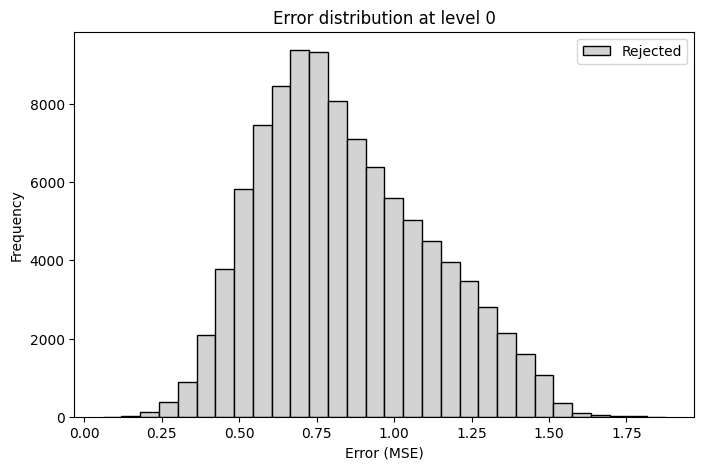

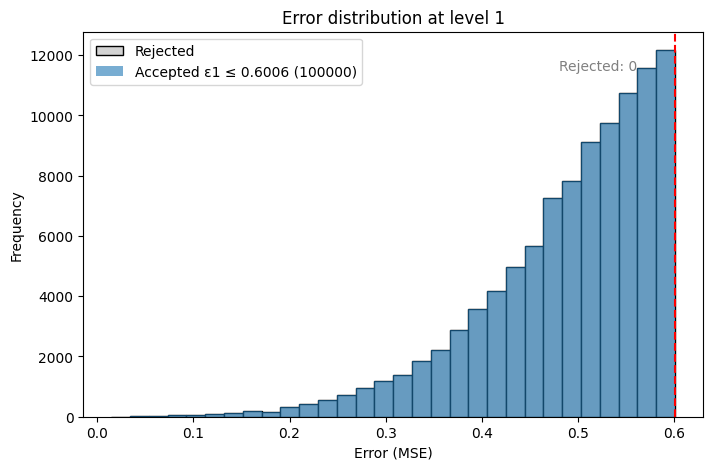

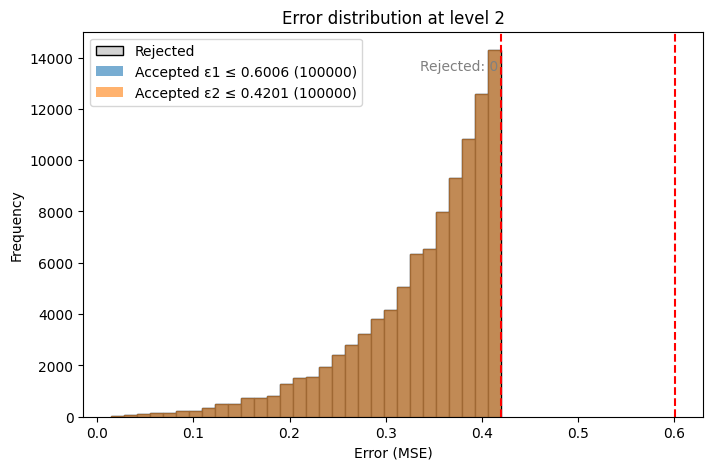

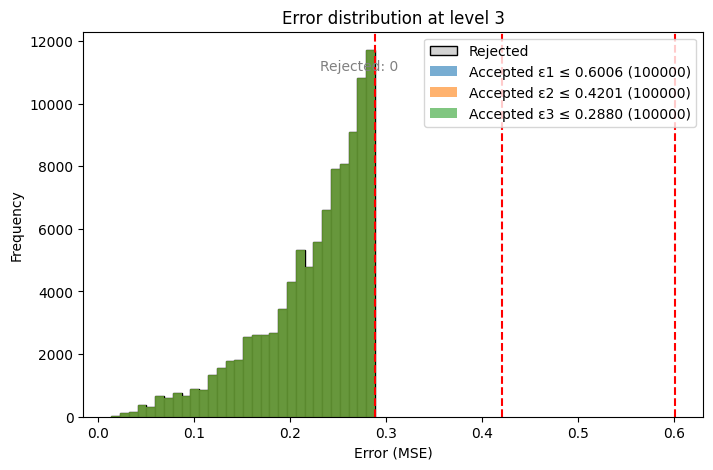

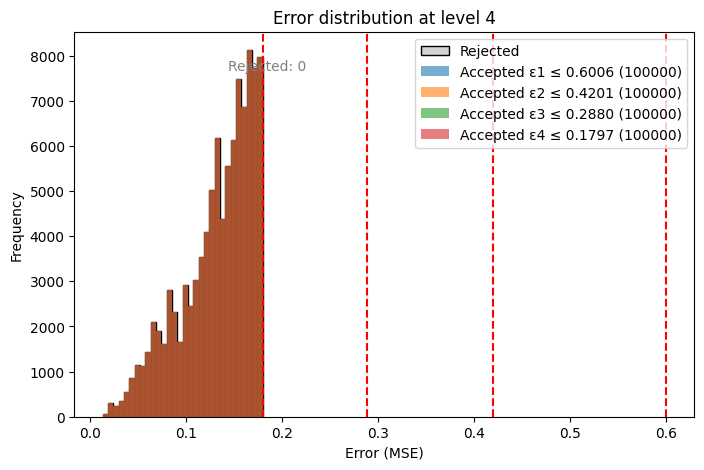

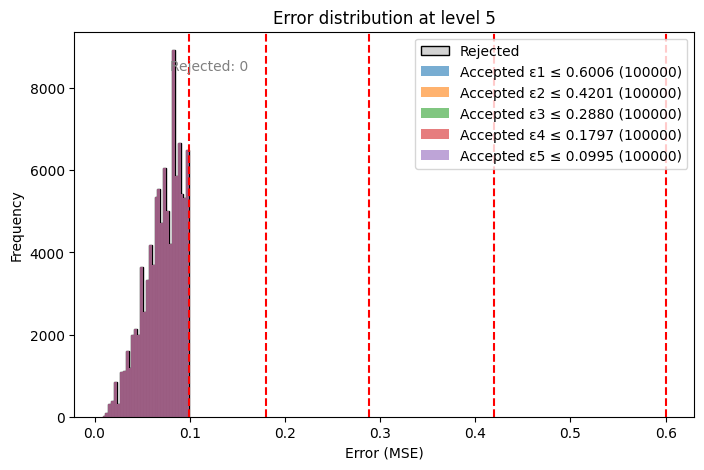

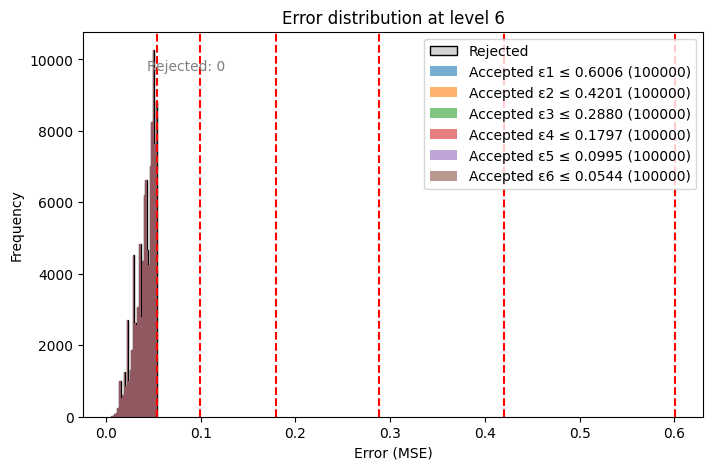

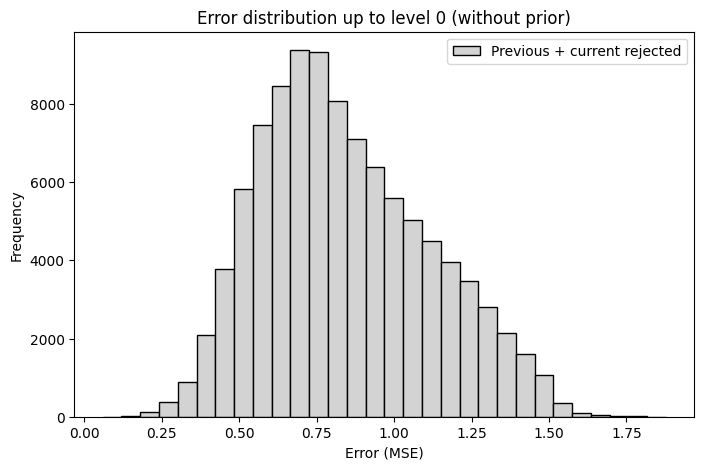

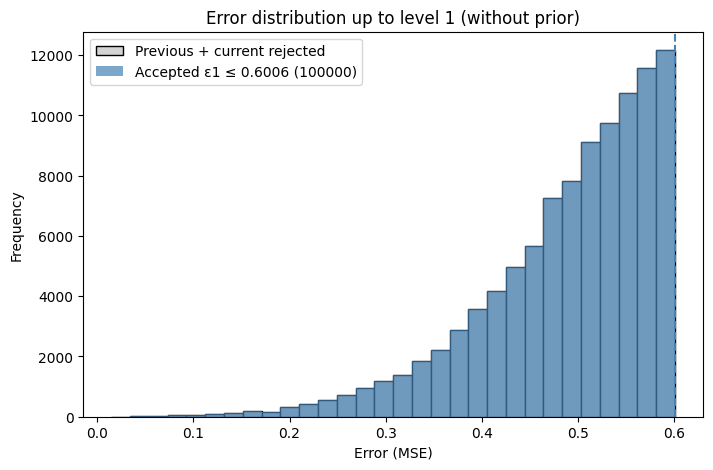

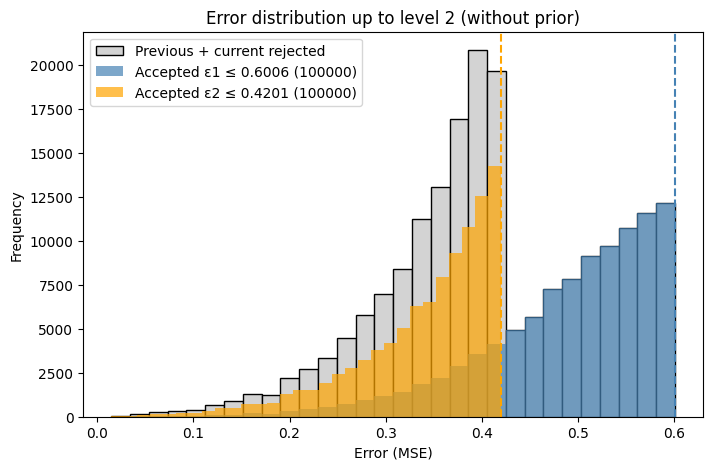

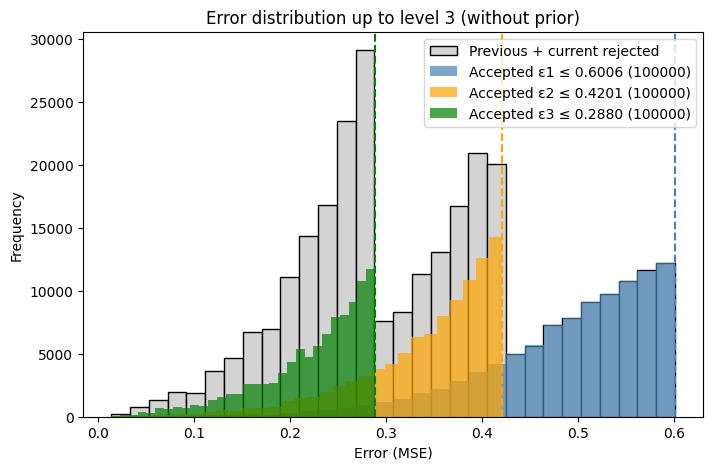

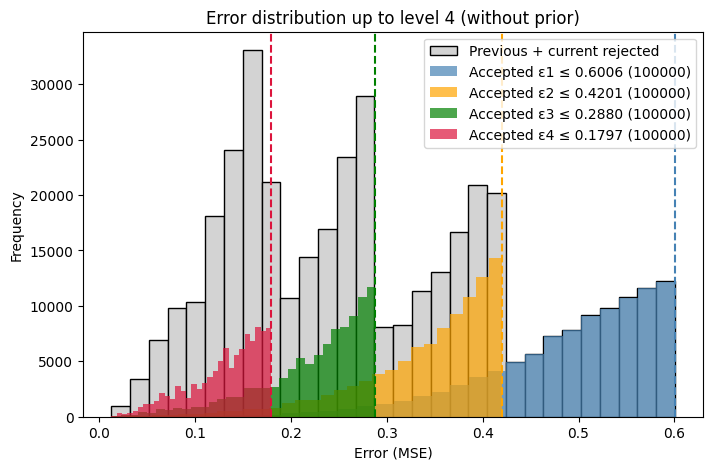

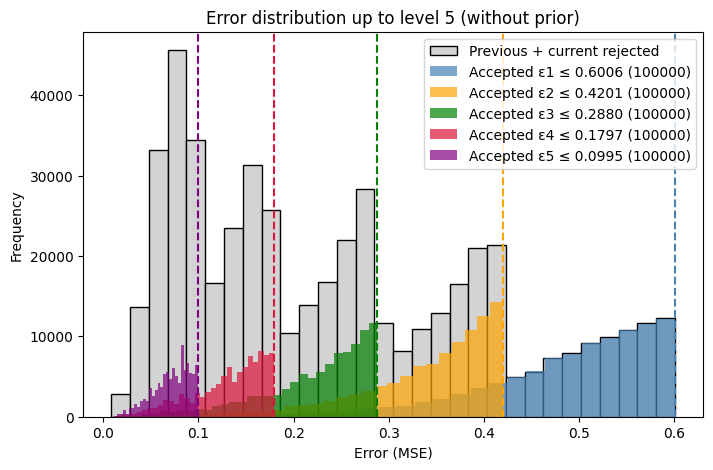

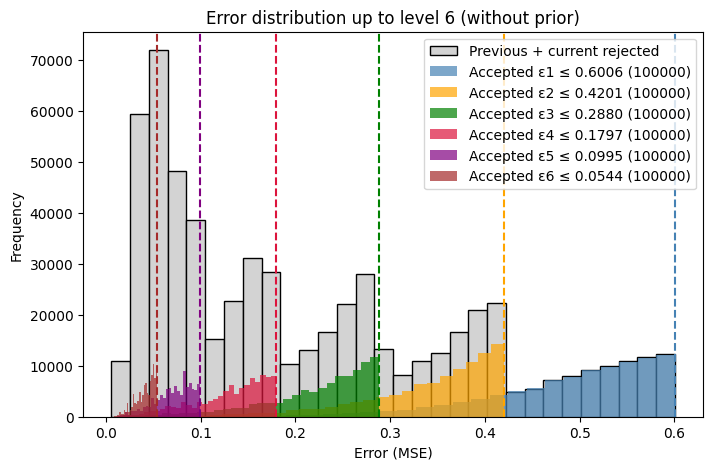

In [39]:
# Histograms per level
for lvl in range(simlevls + 1):  # includes the prior (level 0)
    errors_lvl = ACC_Interm_SS[lvl, :, -1]
    epsilons_lvl = acc_intr_eps[:lvl] if lvl > 0 else []
    plot_error_hist(errors_lvl, epsilons_lvl, level=lvl)

# Cumulative histograms
errors_all_levels = [ACC_Interm_SS[lvl, :, -1] for lvl in range(simlevls + 1)]
for lvl in range(simlevls + 1):
    plot_error_hist_all(errors_all_levels, acc_intr_eps[:lvl], level=lvl)

### 7.2 Predictions per Level

The predictions obtained at each simulation level are compared with the real data:

- The original data series (`Y`) is shown in gray.  
- The predictions (`YFinal[i]`) are drawn in color along with their corresponding error (`eFinal[i]`).  

This allows visualizing how the network's approximation improves as the simulation
levels progress.


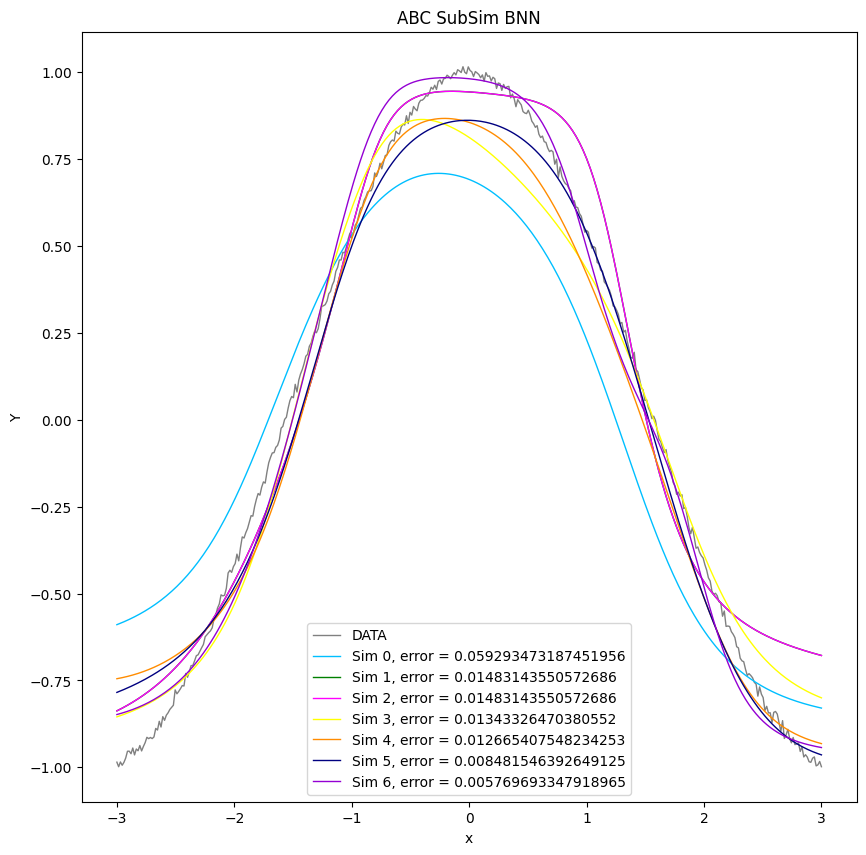

In [40]:
colours = [
    "deepskyblue",
    "green",
    "magenta",
    "yellow",
    "darkorange",
    "navy",
    "darkviolet",
    "springgreen",
    "red",
    "aqua",
    "grey",
]

plt.figure(figsize=(10, 10))
plt.plot(X, Y, label="DATA", color="gray", linewidth=1)

for i in range(len(YFinal)):
    plt.plot(
        X,
        YFinal[i],
        label=f"Sim {i}, error = {eFinal[i]}",
        color=colours[i],
        linewidth=1,
    )

plt.xlabel("x")
plt.ylabel("Y")
plt.title("ABC SubSim BNN")
plt.legend()
plt.show()

### 7.3 Validation on Test Data

The generalization ability of the best model found is evaluated:

- New test data `Xt` is generated in the same training range.  
- The real labels `Yt` are computed by applying the cosine function with noise.  
- The final model prediction (`Ypred_test`) is obtained and its error is calculated.  
- The real data is visually compared with the obtained prediction.


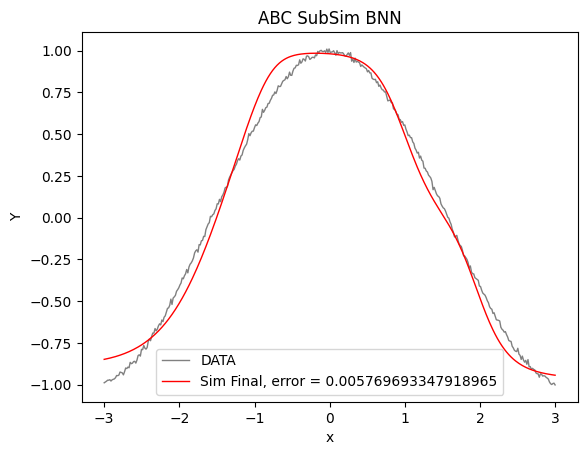

In [41]:
Xt = np.linspace(
    -3, 3, num=N_Inputs
)  # New test data, broader than the training data
Yt = np.cos(Xt) + np.random.normal(0, 0.01, size=N_Inputs)  # Real labels with noise
Xt = Xt.astype(np.float32).reshape((N_Inputs, 1))
Yt = Yt.astype(np.float32).reshape((N_Inputs, 1))

Ypred_test = fpass(Xt, MWtemp, Mbtemp)  # Prediction with the best final model
e_test = metric(Ypred_test, Y)  # Test error
plt.plot(Xt, Yt, label="DATA", color="gray", linewidth=1)
plt.plot(
    Xt,
    Ypred_test,
    label="Sim " + str("Final") + ", error = " + str(e_test),
    color="red",
    linewidth=1,
)
plt.xlabel("x")
plt.ylabel("Y")
plt.title("ABC SubSim BNN")
plt.legend()
plt.show()

### 7.4 Uncertainty Bands

To estimate the model's uncertainty, a prediction matrix is constructed:

- The `per_ind` best parameter samples are selected.  
- Each set of weights and biases is transformed into matrices and evaluated with the test data `Xt`.  
- All predictions are stored in `Y_Matrix`, where each column corresponds to an accepted sample.  

This matrix will be used to compute the mean and percentiles of the predictions.


In [42]:
Y_Matrix = np.zeros(shape=(N_Inputs, per_ind))
for i in range(per_ind):
    Wtemp = Ranked_ABCSampAcc[i, 0:nW]  # Weights of the i-th best sample
    btemp = Ranked_ABCSampAcc[i, nW : nW + nb]  # Corresponding biases
    MWtemp = MatrixW(Wtemp)  # Convert to matrix
    Mbtemp = Matrixb(btemp)
    Ypred_temp = fpass(Xt, MWtemp, Mbtemp)  # Forward pass with Xt
    Y_Matrix[:, i] = Ypred_temp[:, 0]  # Store predictions

### 7.4.1 Mean and Percentiles

From the prediction matrix `Y_Matrix`, the following are computed:

- **Mean (`Y_Mean`)**: average of all accepted predictions at each point `x`.  
- **Mean error (`e_Mean`)**: comparison of the mean with the real data.  
- **Uncertainty interval (5% - 95%)**: the 5th and 95th percentiles are calculated at each point `x`, defining a confidence band for the predictions.


In [43]:
Y_Mean = np.mean(Y_Matrix, axis=1).reshape((N_Inputs, 1))  # Mean at each point x
e_Mean = metric(Y_Mean, Y)  # Mean error
Y_95 = np.percentile(Y_Matrix, 95, axis=1).reshape((N_Inputs, 1))  # 95th percentile
Y_5 = np.percentile(Y_Matrix, 5, axis=1).reshape((N_Inputs, 1))  # 5th percentile

### 7.4.2 Uncertainty Band Visualization

The obtained results are plotted:

- Real data (`Yt`) in gray.  
- Mean of predictions (`Y_Mean`) in blue.  
- Uncertainty bands (5th and 95th percentiles) in red.  

The plot shows both the central tendency and the variability of the predictions,
providing a visual measure of the model's uncertainty.


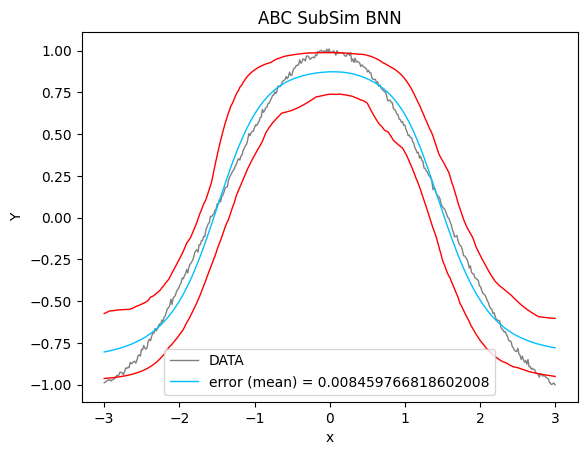

In [44]:
plt.plot(Xt, Yt, label="DATA", color="gray", linewidth=1)
plt.plot(
    Xt, Y_Mean, label="error (mean) = " + str(e_Mean), color="deepskyblue", linewidth=1
)
plt.plot(Xt, Y_95, color="red", linewidth=1)
plt.plot(Xt, Y_5, color="red", linewidth=1)
plt.xlabel("x")
plt.ylabel("Y")
plt.title("ABC SubSim BNN")
plt.legend()
plt.show()

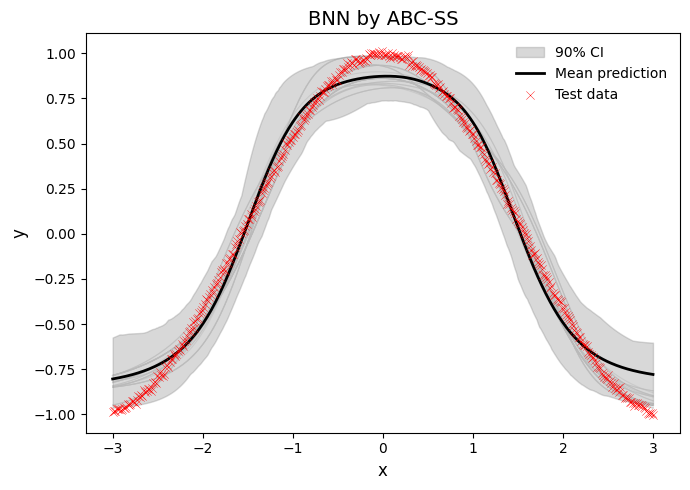

Percentage of points within the 90% band: 88.50%


In [45]:
plt.figure(figsize=(7, 5))

# === Several accepted simulations (light gray, in background) ===
for i in range(min(30, Y_Matrix.shape[1])):
    plt.plot(Xt, Y_Matrix[:, i], color="lightgray", alpha=0.5, linewidth=0.8, zorder=1)

# === 90% uncertainty band (gray, above trajectories) ===
plt.fill_between(
    Xt.flatten(),
    Y_5.flatten(),
    Y_95.flatten(),
    color="gray",
    alpha=0.3,
    label="90% CI",
    zorder=2,
)

# === Predictive mean (black, in front of the band) ===
plt.plot(Xt, Y_Mean, color="black", linewidth=2, label="Mean prediction", zorder=3)

# === Test data (red crosses, always on top) ===
plt.scatter(Xt, Yt, marker="x", color="red", linewidth=0.3, label="Test data", zorder=4)

# === Academic style ===
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("BNN by ABC-SS", fontsize=14)
plt.legend(frameon=False, fontsize=10)
plt.grid(False)
plt.tight_layout()
plt.show()


# Count how many test points fall within the [5%, 95%] band
inside_band = np.logical_and(
    Yt.flatten() >= Y_5.flatten(), Yt.flatten() <= Y_95.flatten()
)

perc_inside = np.mean(inside_band) * 100

print(f"Percentage of points within the 90% band: {perc_inside:.2f}%")

### 7.5 Parameter Distribution

The distribution of the parameters (weights or biases) after the simulation process is analyzed:

- **Histogram**: the distribution of the top 50 best individuals for a specific parameter is plotted.  
- **Smoothed distribution (KDE)**: the probability density is visualized alongside the full histogram, allowing observation of the distribution shape and possible probability concentrations.  

This analysis allows evaluating whether the parameters converge toward specific regions of the search space.


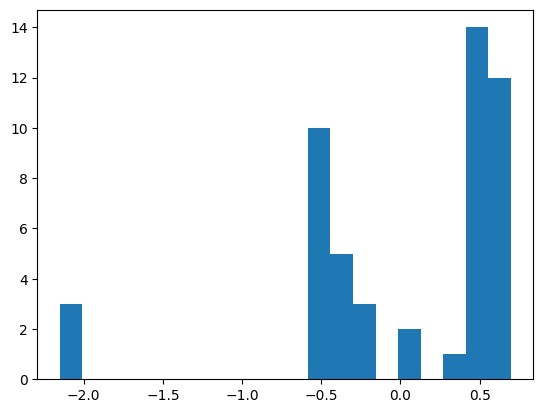

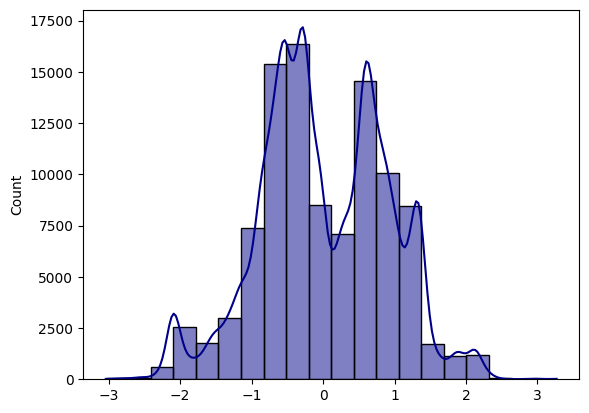

TOTAL TIME: 74.06424236297607s


In [46]:
n_bins = 20

# Histogram of the top 50 best individuals for one parameter
plt.hist(Ranked_ABCSampAcc[0:50, 1], bins=n_bins)
plt.show()

# Smoothed distribution (KDE) of the same parameter
import seaborn as sns

sns.histplot(
    Ranked_ABCSampAcc[:, 1], bins=n_bins, kde=True, color="darkblue", edgecolor="black"
)
plt.show()
end_time = time.time()
total_time = end_time - start_time
print(f"TOTAL TIME: {total_time}s")